# Weighted Survey Logistic Regression for Probable Depression in NHANES 2017–2018

## Step 1: Load libraries

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Step 2: Loading dataset

In [2]:
df = pd.read_csv("merged_final_dataset_eda_nb5.csv")
print(df.shape)
df.columns

(5533, 45)


Index(['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060',
       'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100', 'AgeYears_RIDAGEYR',
       'Sex_RIAGENDR', 'RaceEthnicity1_RIDRETH1', 'EducationAdult_DMDEDUC2',
       'MaritalStatus_DMDMARTL', 'HouseholdIncome_INDDHHIN2',
       'FamilyIncome_INDFMIN2', 'PovertyIncomeRatio_INDFMPIR',
       'BornInUS_DMDBORN4', 'CitizenshipStatus_DMDCITZN', 'YearsInUS_DMDYRSUS',
       'HouseholdSize_DMDHHSIZ', 'FamilySize_DMDFMSIZ',
       'HH_ChildrenUnder6_DMDHHSZA', 'HH_Children6to17_DMDHHSZB',
       'HH_Adults60Plus_DMDHHSZE', 'InterviewWeight_WTINT2YR',
       'ExamWeight_WTMEC2YR', 'PSU_SDMVPSU', 'Strata_SDMVSTRA',
       'phq9_items_answered', 'probable_depression', 'suicidal_ideation',
       'phq9_total_score', 'SurveyCycle_SDDSRVYR', 'ExamMonth_RIDEXMON',
       'MilitaryService_DMQMILIZ', 'InterviewStatus_RIDSTATR',
       'missing_per_participant', 'age_group', 'Gender_Label', 'pir_group',
       'Race_Label', 'Education_Label'],

In [3]:
df.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,SurveyCycle_SDDSRVYR,ExamMonth_RIDEXMON,MilitaryService_DMQMILIZ,InterviewStatus_RIDSTATR,missing_per_participant,age_group,Gender_Label,pir_group,Race_Label,Education_Label
0,93705,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,2.0,2.0,2.0,2,60+,Female,Low (≤1),Non-Hispanic Black,9–11th grade
1,93706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,2.0,2.0,2.0,7,18-29,Male,NaN,Other Race/Multi-racial,NaN
2,93708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,2.0,2.0,2.0,1,60+,Female,Mid (1–2),Other Race/Multi-racial,Less than 9th grade
3,93709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,1.0,2.0,2.0,12,60+,Female,Low (≤1),Non-Hispanic Black,Some college/AA
4,93711,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,2.0,2.0,2.0,0,45-59,Male,High (>2),Other Race/Multi-racial,College graduate Or above


## Step 3: Creating the analytic (complete-case) dataset

In [4]:
model_df = df[[
    "probable_depression",
    "AgeYears_RIDAGEYR",
    "Sex_RIAGENDR",
    "RaceEthnicity1_RIDRETH1",
    "EducationAdult_DMDEDUC2",
    "MaritalStatus_DMDMARTL",
    "PovertyIncomeRatio_INDFMPIR",
    "InterviewWeight_WTINT2YR",
    "pir_group"
]].copy()

model_df["EducationAdult_DMDEDUC2"] = model_df["EducationAdult_DMDEDUC2"].replace([7, 9], np.nan)
model_df["MaritalStatus_DMDMARTL"] = model_df["MaritalStatus_DMDMARTL"].replace([77, 99], np.nan)

analytic_df = model_df.dropna().copy()

**Comments:** I first created a subset of the dataset by specifying the outcome variable, the important sociodemographic predictors, and the NHANES interview weight that is required for the analysis. I then proceeded to recode the invalid survey response categories such as “Refused” and “Don’t know” as missing. I also created a complete case analysis dataset by deleting cases with missing values.

## Step 4 : Creating labeled categorical variables

In [5]:
sex_labels = {1: "Male", 2: "Female"}

race_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
}

education_labels = {
    1: "Less than 9th grade",
    2: "9–11th grade",
    3: "High school/GED",
    4: "Some college/AA",
    5: "College graduate or above"
}

marital_labels = {
    1: "Married",
    2: "Widowed",
    3: "Divorced",
    4: "Separated",
    5: "Never married",
    6: "Living with partner"
}

analytic_df["Sex_RIAGENDR"] = analytic_df["Sex_RIAGENDR"].map(sex_labels)
analytic_df["RaceEthnicity1_RIDRETH1"] = analytic_df["RaceEthnicity1_RIDRETH1"].map(race_labels)
analytic_df["EducationAdult_DMDEDUC2"] = analytic_df["EducationAdult_DMDEDUC2"].map(education_labels)
analytic_df["MaritalStatus_DMDMARTL"] = analytic_df["MaritalStatus_DMDMARTL"].map(marital_labels)

**Comments:** For categorical variables, the numeric NHANES code was mapped onto more interpretable category labels for sex, race and ethnicity, education level, and marital status. This enhances the interpretability of the data for subsequent analysis.

## Step 5: Creating survey weight variable

In [6]:
weights = analytic_df["InterviewWeight_WTINT2YR"]

**Comments**:To account for the complex survey design, interview weights were used to obtain representative results. Since all variables used in this study were derived from the interview portion, the interview weight variable was chosen for all weighted procedures.

## Step 6: Overall Prevalence

### Step 6.1 : Weighted Prevalence by depression

In [7]:
weighted_prevalence = np.average(
    analytic_df["probable_depression"],
    weights=weights
)

print("Weighted prevalence:", weighted_prevalence)

Weighted prevalence: 0.07913293968243237


**Comments:** Weighted prevalence of probable depression was computed using interview weights provided by NHANES data to obtain a representative weighted prevalence. Estimated weighted prevalence is approximately 0.079, meaning that approximately 7.9% of the adult US population is classified as having probable depression.

### Step 6.2: Weighted prevalence by gender

In [8]:
gender_prevalence = analytic_df.groupby("Sex_RIAGENDR").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

gender_prevalence = gender_prevalence.reindex(["Male", "Female"])

gender_prevalence



,Weighted_Prevalence
Sex_RIAGENDR,
Male,0.062672
Female,0.094227


**Comments:** The weighted prevalence of probable depression was also estimated for females and males separately by using the interview weights provided by the NHANES survey. The findings show that the prevalence of probable depression is higher among females than among males. Females have a higher prevalence of 9.4%, while the prevalence among males is significantly lower at 6.3%.

### Step 6.3 : Weighted prevalence by race

In [9]:
race_prevalence = analytic_df.groupby("RaceEthnicity1_RIDRETH1").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

race_prevalence = race_prevalence.reindex([
    "Mexican American",
    "Other Hispanic",
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Other Race"
])

race_prevalence

,Weighted_Prevalence
RaceEthnicity1_RIDRETH1,
Mexican American,0.063841
Other Hispanic,0.079043
Non-Hispanic White,0.079405
Non-Hispanic Black,0.074277
Other Race,0.094902


**Comments:** Weighted prevalence of probable depression was estimated across race/ethnicity groups using interview weights provided by the survey design data. The results show that there is a variation across race/ethnicity groups, with the highest prevalence found in individuals classified as Other Race, approximately 9.5%, and the lowest found in Mexican American individuals, approximately 6.4%. Other race/ethnicity groups, such as Other Hispanic, Non-Hispanic Whites, and Non-Hispanic Blacks, have similar prevalence levels, ranging approximately between 7.4% and 7.9%. This shows that there is a variation in depression prevalence across race/ethnicity groups.

### Step 6.4 : Weighted prevalence by education

In [10]:
education_prevalence = analytic_df.groupby("EducationAdult_DMDEDUC2").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

education_prevalence = education_prevalence.reindex([
    "Less than 9th grade",
    "9–11th grade",
    "High school/GED",
    "Some college/AA",
    "College graduate or above"
])

education_prevalence

,Weighted_Prevalence
EducationAdult_DMDEDUC2,
Less than 9th grade,0.106190
9–11th grade,0.136203
High school/GED,0.088446
Some college/AA,0.087156
College graduate or above,0.047176


**Comments:** The weighted prevalence of probable depression was estimated for different levels of education using the NHANES interview weights to adjust for survey design. The results suggest that there is a declining trend in depression prevalence with increasing educational level. The highest depression prevalence was noted in individuals with an educational level of 9-11th grade, with a prevalence of around 13.6%, followed by individuals with less than 9th grade, with a prevalence of around 10.6%. The depression prevalence for individuals with a high school diploma or GED, as well as for individuals with some college education, was almost similar, with a prevalence of around 8.8% and 8.7%, respectively. In contrast, individuals with a college degree or higher had the lowest depression prevalence, with a value of around 4.7%.

### Step 6.5 : Weighted prevalence by Marital Status

In [11]:
marital_prevalence = analytic_df.groupby("MaritalStatus_DMDMARTL").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

marital_prevalence = marital_prevalence.reindex([
    "Married",
    "Widowed",
    "Divorced",
    "Separated",
    "Never married",
    "Living with partner"
])

marital_prevalence

,Weighted_Prevalence
MaritalStatus_DMDMARTL,
Married,0.052189
Widowed,0.116113
Divorced,0.124784
Separated,0.131177
Never married,0.099266
Living with partner,0.109012


**Comments:** Weighted prevalence of probable depression was calculated for each category of marital status using interview weights provided by NHANES to adjust for survey design. From these data, there is evidence of considerable variation in depression prevalence by marital status. Specifically, those who have been separated have the highest prevalence, approximately 13.1%, while those divorced have a prevalence of approximately 12.5%, and those who have been widowed have a prevalence of approximately 11.6%. Even those who have not married or those living with a partner have a higher prevalence, approximately 9.9% and 10.9%, respectively, while married individuals have the lowest prevalence, approximately 5.2%. These data provide evidence that those not currently in a stable marital relationship may experience a higher burden of depression compared to those married.

### Step 6.6 : Weighted prevalence by PIR

In [12]:
pir_prev = analytic_df.groupby("pir_group").apply(
    lambda x: np.average(
        x["probable_depression"],
        weights=x["InterviewWeight_WTINT2YR"]
    ),
    include_groups=False
).rename("Weighted_Prevalence")

pir_prevalence = pir_prev.reindex([
    "Low (≤1)",
    "Mid (1–2)",
    "High (>2)"
])
pir_prev

,Weighted_Prevalence
pir_group,
High (>2),0.055080
Low (≤1),0.155084
Mid (1–2),0.109062


**Comments:** The weighted prevalence of probable depression in the different groups of poverty income ratios was estimated using the weights generated in the NHANES interviews. The results indicate that there is a clear trend in the prevalence of depression in relation to income levels. The low-income group with a poverty income ratio of less than or equal to 1 has the highest prevalence rate at approximately 15.5%. This is then followed by the middle-income group with a poverty income ratio between 1 and 2, which has a prevalence rate of approximately 10.9%. On the other hand, the high-income group with a poverty income ratio of greater than 2 has the lowest prevalence rate at approximately 5.5%. This indicates that the income level is inversely proportional to the prevalence rate of probable depression.

## Step 7 : Graphical representation of weighted prevalence of probable depression

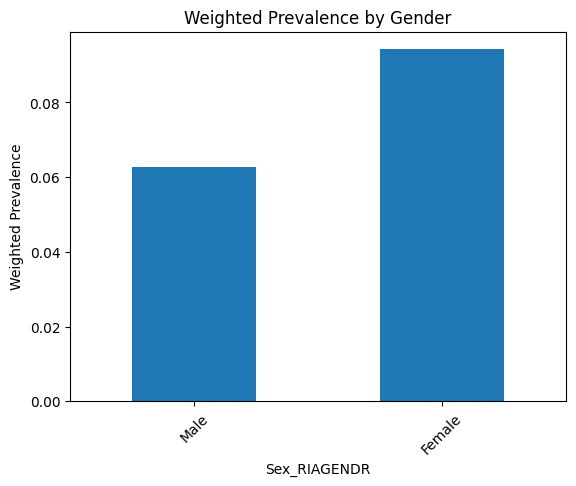

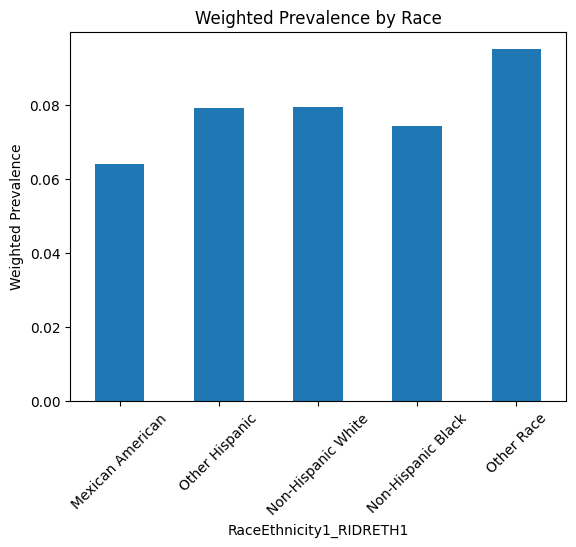

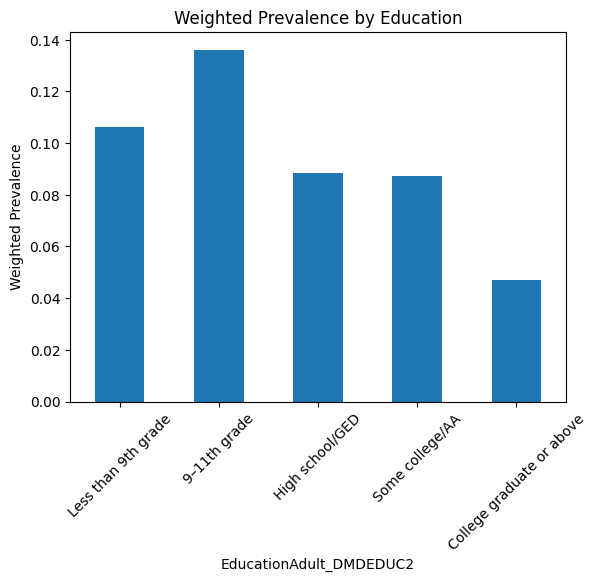

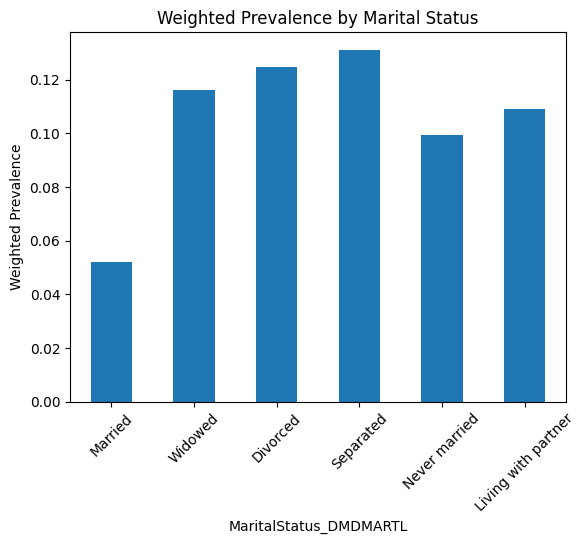

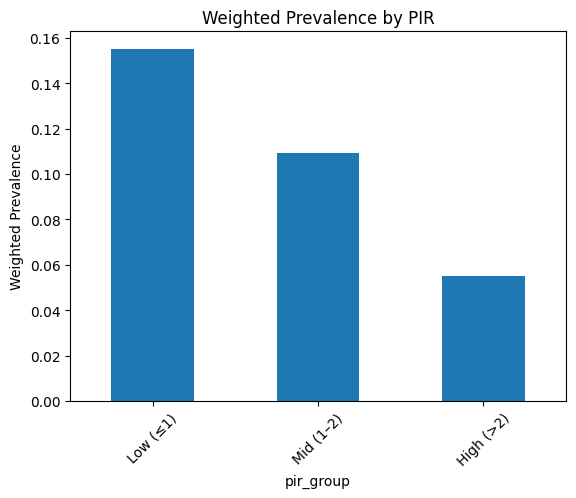

In [13]:
import matplotlib.pyplot as plt

def plot_bar(data, title):
    data.plot(kind="bar")
    plt.ylabel("Weighted Prevalence")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# Plotting all
plot_bar(gender_prevalence, "Weighted Prevalence by Gender")
plot_bar(race_prevalence, "Weighted Prevalence by Race")
plot_bar(education_prevalence, "Weighted Prevalence by Education")
plot_bar(marital_prevalence, "Weighted Prevalence by Marital Status")
plot_bar(pir_prevalence, "Weighted Prevalence by PIR")

**Comments** Bar plots were used to visually represent the weighted prevalence of probable depression across sociodemographic groups. The values in the bar plots align with the previously calculated weighted prevalence values and provide a clear visual representation of the differences between them.

## Step 8: Confidence Intervals

In [14]:
# Function to calculate weighted mean and 95% CI
def weighted_ci(data, weight_col, outcome):

    w = data[weight_col]
    y = data[outcome]

    # Weighted mean
    mean = np.average(y, weights=w)

    # Weighted variance
    var = np.average((y - mean)**2, weights=w)

    # Standard error
    se = np.sqrt(var / len(data))

    # 95% CI
    ci = 1.96 * se

    return pd.Series({
        "Mean": mean,
        "Lower_CI": mean - ci,
        "Upper_CI": mean + ci
    })


# Applying to all variables

# Gender
gender_ci = analytic_df.groupby("Sex_RIAGENDR").apply(
    lambda x: weighted_ci(x, "InterviewWeight_WTINT2YR", "probable_depression"),
    include_groups=False
)

# Race
race_ci = analytic_df.groupby("RaceEthnicity1_RIDRETH1").apply(
    lambda x: weighted_ci(x, "InterviewWeight_WTINT2YR", "probable_depression"),
    include_groups=False
)

# Education
education_ci = analytic_df.groupby("EducationAdult_DMDEDUC2").apply(
    lambda x: weighted_ci(x, "InterviewWeight_WTINT2YR", "probable_depression"),
    include_groups=False
)

# Marital
marital_ci = analytic_df.groupby("MaritalStatus_DMDMARTL").apply(
    lambda x: weighted_ci(x, "InterviewWeight_WTINT2YR", "probable_depression"),
    include_groups=False
)

# PIR
pir_ci = analytic_df.groupby("pir_group").apply(
    lambda x: weighted_ci(x, "InterviewWeight_WTINT2YR", "probable_depression"),
    include_groups=False
)


# Displaying all results
gender_ci, race_ci, education_ci, marital_ci, pir_ci

(                  Mean  Lower_CI  Upper_CI
 Sex_RIAGENDR                              
 Female        0.094227  0.082432  0.106021
 Male          0.062672  0.052562  0.072781,
                              Mean  Lower_CI  Upper_CI
 RaceEthnicity1_RIDRETH1                              
 Mexican American         0.063841  0.043824  0.083858
 Non-Hispanic Black       0.074277  0.058324  0.090229
 Non-Hispanic White       0.079405  0.066414  0.092396
 Other Hispanic           0.079043  0.052668  0.105419
 Other Race               0.094902  0.075625  0.114178,
                                Mean  Lower_CI  Upper_CI
 EducationAdult_DMDEDUC2                                
 9–11th grade               0.136203  0.106346  0.166061
 College graduate or above  0.047176  0.034720  0.059632
 High school/GED            0.088446  0.071666  0.105226
 Less than 9th grade        0.106190  0.073774  0.138606
 Some college/AA            0.087156  0.072872  0.101440,
                             Mean  Lo

**Comments:**
The calculation of the 95% confidence intervals was used to determine the level of uncertainty in relation to the weighted prevalence estimates for probable depression among different sociodemographic groups.

Overall, it is seen that the results are stable and reliable, as indicated by the narrow range in the confidence intervals. When comparing the prevalence rates for probable depression between genders, it is seen that females have a higher prevalence rate compared to males. This is also indicated by the lack of overlap in the results for both groups.

When comparing the prevalence rates for probable depression among different racial and ethnic groups, it is seen that while there is some overlap in the results for different groups, individuals in the Other Race group have relatively higher rates compared to others.

As far as educational status is concerned, a gradient is evident, showing higher prevalence among people with low educational status, i.e., 9–11th grade, and the lowest among people who are graduates.

As far as the marital status of the people is concerned, the highest prevalence is among people who are separated, divorced, or widowed, and the lowest among married people.

As far as the poverty income ratio is concerned, the highest prevalence is among people in the low income group, and the lowest among people in the high income group.

## Step 9: Statistical Testing (Chi-square)

In [15]:
from scipy.stats import chi2_contingency

# Gender
gender_table = pd.crosstab(analytic_df["Sex_RIAGENDR"], analytic_df["probable_depression"])
chi2_gender = chi2_contingency(gender_table)

# Race
race_table = pd.crosstab(analytic_df["RaceEthnicity1_RIDRETH1"], analytic_df["probable_depression"])
chi2_race = chi2_contingency(race_table)

# Education
education_table = pd.crosstab(analytic_df["EducationAdult_DMDEDUC2"], analytic_df["probable_depression"])
chi2_education = chi2_contingency(education_table)

# Marital
marital_table = pd.crosstab(analytic_df["MaritalStatus_DMDMARTL"], analytic_df["probable_depression"])
chi2_marital = chi2_contingency(marital_table)

# PIR
pir_table = pd.crosstab(analytic_df["pir_group"], analytic_df["probable_depression"])
chi2_pir = chi2_contingency(pir_table)

# Printing p-values
print("Gender p-value:", chi2_gender[1])
print("Race p-value:", chi2_race[1])
print("Education p-value:", chi2_education[1])
print("Marital Status p-value:", chi2_marital[1])
print("PIR p-value:", chi2_pir[1])

Gender p-value: 0.00015207796194595727
Race p-value: 0.012485893374981199
Education p-value: 1.179043537444324e-06
Marital Status p-value: 1.1883044260122798e-10
PIR p-value: 7.432420599700787e-12


In [16]:
gender_table = pd.crosstab(analytic_df["Sex_RIAGENDR"], analytic_df["probable_depression"])
gender_table


probable_depression,0,1
Sex_RIAGENDR,,
Female,2130,227
Male,2064,144


In [17]:
chi2_contingency(gender_table)

Chi2ContingencyResult(statistic=np.float64(14.346303808395959), pvalue=np.float64(0.00015207796194595727), dof=1, expected_freq=array([[2165.44534502,  191.55465498],
       [2028.55465498,  179.44534502]]))

**Comments**
The results of the chi-square tests show that all the sociodemographic factors are significantly associated with probable depression. The results show that gender has a statistically significant association with depression prevalence. This shows that there are differences between men and women. In addition, race and ethnicity have a significant association with depression. This shows that there are differences between people of different racial and ethnic groups. The results show that education level has a significant association with depression. This shows that there are differences between people of different education levels. In addition, marital status has a significant association with depression. This shows that there are differences between people of different marital statuses. Lastly, poverty-income ratio has a highly significant association with probable depression. This shows that socioeconomic factors play a crucial role in depression. From the results, it can be concluded that depression prevalence is not equal across all people.

## Step 10: Multivariable logistic regression analysis

### Model 1

In [18]:
import statsmodels.formula.api as smf

# Logistic regression model
model = smf.logit(
    "probable_depression ~ AgeYears_RIDAGEYR + C(Sex_RIAGENDR) + C(RaceEthnicity1_RIDRETH1) + C(EducationAdult_DMDEDUC2) + C(MaritalStatus_DMDMARTL) + PovertyIncomeRatio_INDFMPIR",
    data=analytic_df
).fit()

# Summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.267927
         Iterations 7
                            Logit Regression Results                           
Dep. Variable:     probable_depression   No. Observations:                 4565
Model:                           Logit   Df Residuals:                     4548
Method:                            MLE   Df Model:                           16
Date:                 Fri, 27 Mar 2026   Pseudo R-squ.:                 0.04944
Time:                         20:44:40   Log-Likelihood:                -1223.1
converged:                        True   LL-Null:                       -1286.7
Covariance Type:             nonrobust   LLR p-value:                 2.215e-19
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept 

**Comments:** A multivariable logistic regression model has also been fitted to determine the association between the sociodemographic factors and probable depression.

The results show that the odds ratio for depression in males is less compared to females. Among the race and ethnicity groups, the odds ratio for Non-Hispanic White is higher and statistically significant compared to the reference group.

The odds ratio for the education level, which is college graduates, is less and statistically significant. The odds ratio for the marital status of married individuals is less and statistically significant. The odds ratio for individuals living with their partners is higher and statistically significant.

The odds ratio for the poverty income ratio is also statistically significant, indicating that the higher the income level, the less the odds ratio for depression. The odds ratio for age is not statistically significant.

From the logistic regression model, it is evident that the factors that determine depression are gender, education level, marital status, and income level.

### Model 2 - Removing Variables

We are removing variables with no effect for the second model and keeping the variables with effect.

The age variable was also removed since it did not show any statistically significant association with the outcome variable, with a p-value of 0.330. This indicates that the variable has no association with the occurrence of depression. In addition, the race and ethnicity variable were removed since the majority of the categories did not show any statistically significant association with the outcome variable, with Non-Hispanic Black individuals having a p-value of 0.783, Other Hispanic individuals having a p-value of 0.558, and Other Races having a p-value of 0.638. This indicates that the variable has no association with depression. However, other variables like gender with a p-value of 0.001, poverty income ratio with a p-value of less than 0.001, education level with a p-value of less than 0.001 for college graduates, and marital status with a p-value of less than 0.001 for married individuals and 0.022 for individuals living with their partners were considered important variables that show association with depression.

In [19]:
model2 = smf.logit(
    "probable_depression ~ C(Sex_RIAGENDR) + C(EducationAdult_DMDEDUC2) + C(MaritalStatus_DMDMARTL) + PovertyIncomeRatio_INDFMPIR",
    data=analytic_df
).fit()

print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.269583
         Iterations 7
                            Logit Regression Results                           
Dep. Variable:     probable_depression   No. Observations:                 4565
Model:                           Logit   Df Residuals:                     4553
Method:                            MLE   Df Model:                           11
Date:                 Fri, 27 Mar 2026   Pseudo R-squ.:                 0.04356
Time:                         20:44:40   Log-Likelihood:                -1230.6
converged:                        True   LL-Null:                       -1286.7
Covariance Type:             nonrobust   LLR p-value:                 6.966e-19
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept 

The refined logistic regression model was developed after removing non-significant factors such as age and race. The results show that gender is still significant in the model, indicating that males have lower odds of probable depression compared to females. However, gender is still significant in the model. The results further indicate that education is significant in the model; however, it is only significant in individuals who are college graduates (p = 0.002). Marital status is still significant in the model; however, it is significant in individuals who are married (p < 0.001), indicating that they have lower odds of depression. Marital status is also significant in individuals who live with their partner (p = 0.024), indicating that they also have lower odds of depression. Poverty-income ratio is still significant in the model; however, it is highly significant in the model.

Several factors in education and marital status were found to be non-significant; therefore, further refinement of the model is required.

### Model 3 - Refining categories

Another refined version of the logistic regression model was developed by grouping the less relevant categories into one called "Other" in the education and marital status variables. This ensured the retention of the full sample, making the model simpler by focusing on the most significant predictors of probable depression.

### Recode variables

In [22]:
# Education: keep College graduate, others grouped
analytic_df["edu_final"] = analytic_df["EducationAdult_DMDEDUC2"].apply(
    lambda x: x if x in ["9–11th grade", "College graduate or above"] else "Other"
)

# Marital: keep Married and Living with partner, others grouped
analytic_df["marital_final"] = analytic_df["MaritalStatus_DMDMARTL"].apply(
    lambda x: x if x in ["Divorced", "Married", "Living with partner"] else "Other"
)

In [23]:
model3 = smf.logit(
    "probable_depression ~ C(Sex_RIAGENDR) + "
    "C(edu_final, Treatment(reference='9–11th grade')) + "
    "C(marital_final, Treatment(reference='Divorced')) + "
    "PovertyIncomeRatio_INDFMPIR",
    data=analytic_df
).fit()

print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.269696
         Iterations 7
                            Logit Regression Results                           
Dep. Variable:     probable_depression   No. Observations:                 4565
Model:                           Logit   Df Residuals:                     4557
Method:                            MLE   Df Model:                            7
Date:                 Fri, 27 Mar 2026   Pseudo R-squ.:                 0.04316
Time:                         20:55:19   Log-Likelihood:                -1231.2
converged:                        True   LL-Null:                       -1286.7
Covariance Type:             nonrobust   LLR p-value:                 5.512e-21
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

The ‘Other’ options for education and marital status were retained in the model as it maintained the full structure of the categorical variables. Although the ‘Other’ options were not statistically significant, it is a very important comparison group.

**Comments:**
Based on the refined logistic regression model, it was established that a number of variables are significantly related to probable depression. For instance, gender was a significant predictor in that the odds ratio for males experiencing depression was significantly lower than that of the female population (p = 0.001). Furthermore, the education level was also a significant predictor in that the odds ratio for the population with a college graduate education level or higher was significantly lower than that of the population with a 9-11th grade education level (p = 0.001), whereas the “Other” education level was not statistically significant (p = 0.106).

Moreover, the marital status was a significant predictor in that the odds ratio for the population that lived with a partner (p = 0.025) and the ones that were married (p < 0.001) was significantly lower than that of the divorced population, whereas the “Other” marital status was not statistically significant (p = 0.097).

Lastly, the poverty income ratio was a significant predictor in that the odds ratio for the population with a higher income was significantly lower than that of the population with a lower income (p < 0.001).

## Step 11: Convert to Odds Ratios

In [24]:
import numpy as np
np.exp(model3.params)

,0
Intercept,0.337346
C(Sex_RIAGENDR)[T.Male],0.688962
"C(edu_final, Treatment(reference='9–11th grade'))[T.College graduate or above]",0.501556
"C(edu_final, Treatment(reference='9–11th grade'))[T.Other]",0.778291
"C(marital_final, Treatment(reference='Divorced'))[T.Living with partner]",0.615980
"C(marital_final, Treatment(reference='Divorced'))[T.Married]",0.458152
"C(marital_final, Treatment(reference='Divorced'))[T.Other]",0.769862
PovertyIncomeRatio_INDFMPIR,0.833678


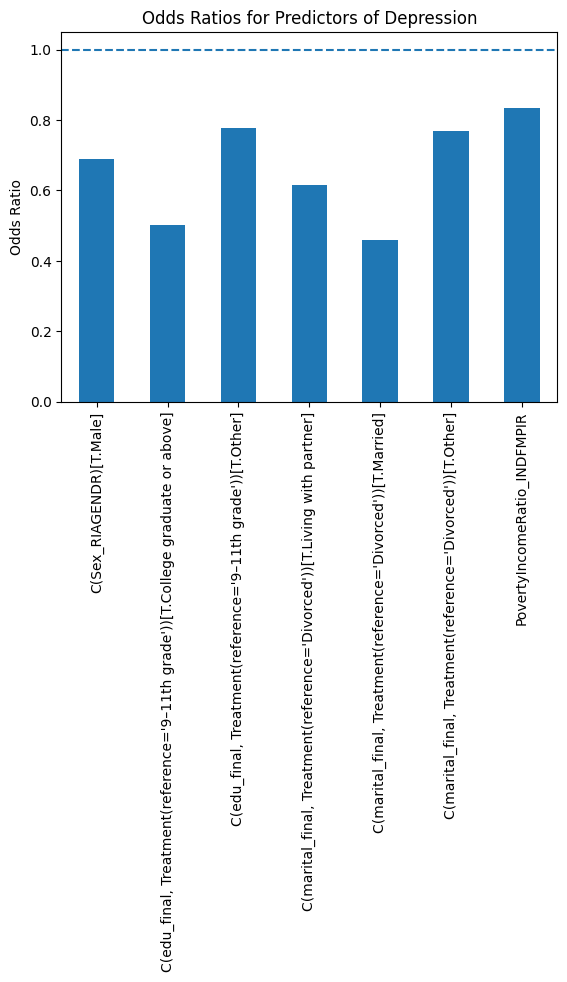

In [26]:
#Visualization
import matplotlib.pyplot as plt

np.exp(model3.params).drop("Intercept").plot(kind="bar")
plt.ylabel("Odds Ratio")
plt.title("Odds Ratios for Predictors of Depression")
plt.axhline(y=1, linestyle='--')
plt.show()

**Comments:** The logistic regression coefficients were converted into odds ratios to make the results easier to interpret. The results show that males have lower odds than females in developing probable depression (OR = 0.69). Moreover, individuals who have a college graduate education or above have substantially lower odds in developing depression compared to individuals who have 9-11th grade education (OR = 0.50). In addition, the "Other" education variable is not statistically significant. Regarding the variable "Marital Status," individuals who are living with a partner have lower odds in developing depression compared to divorced individuals (OR = 0.62), as well as individuals who are married (OR = 0.46). Moreover, the "Other" variable in the "Marital Status" question is not statistically significant. Furthermore, the poverty income ratio is inversely related to depression, as individuals who have higher income have lower odds in developing probable depression (OR = 0.83). Overall, the results show that individuals who have higher education, stable relationships, and higher income status are less likely to develop depression.

I kept ‘Other’ to avoid losing data and to maintain proper category comparisons in the regression model.”

## Step 12: Final Conclusion and Interpretation

The present study aimed to identify the prevalence and sociodemographic factors of probable depression in adults in the United States using data from the 2017-2018 NHANES. Data cleaning and preparation are critical steps in any data analysis process. In this case, it involved ensuring that missing and special coded values are appropriately handled. Then, demographic and mental health data are merged. In this case, some exploratory analysis was conducted in the preceding notebooks.

In Notebook 6, more in-depth analysis was conducted by using weights provided by the NHANES interview weights. From these analyses, it was evident that depression is not distributed evenly across different sociodemographic populations. For instance, it is more prevalent in female populations than male populations. In addition, depression is more prevalent in populations with lower educational attainment and those in lower income brackets. Chi-square tests showed that depression prevalence is significantly different across different gender populations, racial populations, educational populations, marital populations, and income populations.

To establish relationships between depression and these factors, logistic regression analysis was conducted. In this case, the original model consisted of age, gender, racial group, educational level, marital status, and income level. After refining this model, some factors like age and racial group were removed since they are not statistically significant. In addition, some factors like educational level and marital status are grouped for simplicity and ease of interpretation. From this analysis, it is evident that factors like gender, educational level, marital status, and income level are all statistically significant in determining probable depression.

The interpretation of odds ratio results showed that males have lower odds of depression compared to females. Individuals with college education and beyond have lower odds compared to those with lower levels of education. Similarly, individuals who are married or living with someone have lower odds of depression compared to divorced individuals. In addition, individuals with higher poverty income ratio have lower odds of depression, implying that better economic conditions have lower odds of depression.

From the results, it is evident that depression is not equally distributed in society. It is evident that depression is greatly determined by various social and economic factors. Individuals with higher levels of education, those who are married or living with someone, and those in better economic conditions have lower odds of depression. The results emphasize the need to focus on social and economic disparities in addressing depression.

## Step 13: Save Final Processed Dataset

In [27]:
analytic_df.to_csv("final_analytic_dataset_nb6.csv", index=False)